In [1]:
import numpy as np 
import warnings
from scipy.optimize import root_scalar
import model_constants as const
import pandas as pd
from scipy.stats import gamma,norm 
from scipy.integrate import cumulative_trapezoid
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
####
# A Python version of the zero buoyancy plume model in Singh and O'Gorman (2013).
# With modifications following Zhou and Xie (2019).
# >> Input parameters are:

# T_base : Base temperature of plume (K)
# qt_base: Base specific humidity of plume (kg/kg)
# p_base : Base pressure of plume (Pa)
# entrain: entrainment parameter (unitless)
#          Depends on "ent_type" (see optional arguments below)
#                 entrainment = entrain/z    [default]
#                 entrainment = entrain/1000
# RH     : environmental relative humidity (unitless, between 0 and 1)

# >> Optional arguments are:

# z_base  : Base height of plume (m) [50 m by default]
# z_top   : height to which pluem is integrated (m) [15000 m by default]
# gamma   : fraction of water that precipitates (0, 1) [1 by default]
#           0 = no fallout
#           1 = pseudo-adiabatic (all condensed water falls out immediately)
# ent_type: type of entrainment profile ['invz']
#         'invz': entrainment = entrain/z    [default]
#         'const': entrainment = entrain/1000
# deltaz  : vertical grid-spacing (m) [50 m by default]
# T_ice   : Temperature of total freezing condensate freezes 
#          gradually between 273.15 K and T_ice (K) [233.15 K by default]

# >> Outputs are:
# T_rho   : Density temperature (plume and env)   (K)
# T       : Temperature of plume                  (K)
# p       : pressure            (plume and env)   (K)
# qv      : specific humidity of plume            (kg/kg)
# qsat    : saturation specific humidity of plume (kg/kg)
# ql      : liquid water mass fraction of plume   (kg/kg)
# qi      : solid water mass fraction of plume    (kg/kg)
# z       : height                                (z)
# h       : plume moist static energy             (J/kg)
# T_env   : Temperature of environment            (K)
# q_env   : specific humidity of environment      (kg/kg)
# h_env   : environment moist static energy       (J/kg)
# ent     : entrainment rate                      (1/m)
#####

In [3]:
### function to check arguments are correct
def check_argument(var, varname, expected_type, varmin, varmax):
    """
    Check that an argument has the expected type and, if numeric,
    lies within the given bounds.

    Parameters
    ----------
    var : any
        Value to check.
    varname : str
        Name of the variable, used in error messages.
    expected_type : type or tuple[type, ...]
        Expected Python type, e.g. float, int, str, or (int, float).
    varmin : float
        Minimum allowed value for numeric inputs.
    varmax : float
        Maximum allowed value for numeric inputs.
    """
    if not isinstance(var, expected_type):
        if isinstance(expected_type, tuple):
            type_name = ", ".join(t.__name__ for t in expected_type)
        else:
            type_name = expected_type.__name__
        raise TypeError(f"Input: {varname} must be of type {type_name}")

    if isinstance(var, (int, float)):
        if var < varmin or var > varmax:
            raise ValueError(
                f"Input: {varname} outside of bounds [{varmin}, {varmax}]"
            )
    

In [4]:
def calc_fice(T, const=const):
    # Function to calculate the fraction of condensate that is ice.
    # All liquid for T > T0
    # All ice for T < T_ice
    # Linear function in between

    fliq = ( T-const.T_ice )/(const.T0-const.T_ice)
    if type(fliq)==float or type(fliq)==np.float64:
        if fliq<0:
            fliq=0
        elif fliq>1:
            fliq=1
    else:
        fliq[fliq<0] = 0
        fliq[fliq>1] = 1
    fice = 1-fliq

    return fliq, fice


def e_sat(T,const=const):
    # Function to calculate the saturation vapor pressure
    #
    # The functions are consistent with the constants given in the
    # model_constants subroutine. A faster option is available in which the
    # saturation curves are approximated as in Bolton (1980).
    #

    # Thermodynamically consistent definition of saturation curves
    # i.e. integral of Clausius-Clapeyron equation with constant heat
    # capacities. See Romps (2008).

    esl = const.e0*(T/const.T0)**((const.cpv-const.cpl)/const.Rv)* np.exp( ( const.Lv0 - const.T0*(const.cpv-const.cpl) )/const.Rv* ( 1/const.T0 - 1/T ) )

    esi = const.e0*(T/const.T0)**((const.cpv-const.cpi)/const.Rv)*np.exp( ( const.Ls0 - const.T0*(const.cpv-const.cpi) )/const.Rv* ( 1/const.T0 - 1/T ) )

    # If you want slightly faster (~10#) code, use these approximations 
    # (Bolton, 1980). Accurate to within 0.5# for T < 310 K.

    # esl = 611.2 *np. exp( 17.67      * ( T  - 273.15 ) / ( T  - 29.65 ) )
    # esi = 611.2 *np.exp( 21.8745584 * ( T  - 273.15 ) / ( T  - 7.66  ) )


    # Calculate ice fraction
    fliq,fice = calc_fice(T)

    es = fliq*esl + fice*esi

    return es, esl, esi

def qq_sat(T,p,qt=None, const=const):
    # Function to calculate the saturation specific humidity

    # Calculate saturation mixing ratio
    es, esl, esi = e_sat(T)
    rs = const.eps*es/(p-es)

    # Calculate saturation specific humidity using total water content if given
    if qt is not None:
        
        rt = qt/(1-qt)
        qs = rs/(1+np.nanmax([rt,rs]))
    else:
        qs = rs/(1+rs)
    
    return qs

def calc_saturation(p,T,q_t):
    # Function to calculate the specific humidities of vapor, liquid and solid
    # at saturation
    # calculate saturation specific humidity
    qs = qq_sat(T,p,q_t)
    q = np.minimum(q_t,qs)
    if type(q)==np.float64:
        if q<0:
            q=0
    else:
        q[q<0] = 0

    # Divide into liquid and ice
    fliq,fice = calc_fice(T)

    ql = fliq*(q_t-q)
    qi = fice*(q_t-q)

    if type(ql)==np.float64:
        if q_t-qs<0:
            ql=0
            qi=0
    else:
        ql[q_t-qs<0] = 0
        qi[q_t-qs<0] = 0


    return q,ql,qi

In [5]:
def calc_MSE(T,qt,p,z,const=const):
    # Function to calculate moist static energy

    # calculate proportions of vapor, liquid and solid
    qv,ql,qi = calc_saturation(p,T,qt)


    # calculate moist static energies of components
    hd = const.cp*(T-const.T0)  + const.g*z
    hv = const.cpv*(T-const.T0) + const.g*z + const.Lv0
    hl = const.cpl*(T-const.T0) + const.g*z
    hi = const.cpi*(T-const.T0) + const.g*z - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    ## Remove liquid and ice effect
    h = hd*(1-qt) + qv*hv #+ ql*hl + qi*hi

    return h

In [6]:
def calc_Tv(T,RH,p,const=const):
    # Function to calculate virtual temperature at a given relative humidity

    # Calculate mixing ratio
    es, esl, esi  = e_sat(T)
    qv = const.eps*(RH*es/(p-RH*es*(1-const.eps)))

    # calculate virtual temperature
    Tv = T*(1+qv/const.eps-qv)

    return Tv

In [7]:
def fallout(gamma,ql,qi,dqls,T):
    # Function to calculate precipitation fallout terms

    e = np.minn([0,dqls/(1-ql-qi) ])

    fT = -gamma*e
    fliq,fice = calc_fice(T)

    fl = fT*fliq
    fs = fT*fice

    return fl, fs

In [8]:
def p_from_z(z0, z_lcl, p0, Tv_mean=298.0,const=const):
    """Approximate pressure at LCL height from hypsometric relation."""
    return p0 * np.exp(const.g * (z0-z_lcl) / (const.Rd * Tv_mean))

def q0_for_target_lcl(T0, p0, p_lcl,const=const):
    """
    Surface specific humidity required so that the parcel LCL is at p_lcl.
    """
    kappa = const.Rd / const.cp
    T_lcl = T0 * (p_lcl / p0) ** kappa
    q0 = qq_sat(T_lcl, p_lcl)
    return q0, T_lcl

def q0_for_target_lcl_height(T0, p0, z0, z_lcl, const=const):
    """
    Surface specific humidity required so that the parcel LCL is at z_lcl.
    """
    ### Assuming dry adiabat 
    Tv_mean = T0 - 1/2 * const.g/const.cp*z_lcl
    
    p_lcl = p_from_z(z0, z_lcl, p0, Tv_mean, const)
    q0, T_lcl = q0_for_target_lcl(T0, p0, p_lcl, const)
    return q0, p_lcl, T_lcl


In [9]:
### function to check arguments are correct
def check_argument(var, varname, expected_type, varmin, varmax):
    """
    Check that an argument has the expected type and, if numeric,
    lies within the given bounds.

    Parameters
    ----------
    var : any
        Value to check.
    varname : str
        Name of the variable, used in error messages.
    expected_type : type or tuple[type, ...]
        Expected Python type, e.g. float, int, str, or (int, float).
    varmin : float
        Minimum allowed value for numeric inputs.
    varmax : float
        Maximum allowed value for numeric inputs.
    """
    if not isinstance(var, expected_type):
        if isinstance(expected_type, tuple):
            type_name = ", ".join(t.__name__ for t in expected_type)
        else:
            type_name = expected_type.__name__
        raise TypeError(f"Input: {varname} must be of type {type_name}")

    if isinstance(var, (int, float)):
        if var < varmin or var > varmax:
            raise ValueError(
                f"Input: {varname} outside of bounds [{varmin}, {varmax}]"
            )
    


# %%
def calc_fice(T, const=const):
    # Function to calculate the fraction of condensate that is ice.
    # All liquid for T > T0
    # All ice for T < T_ice
    # Linear function in between

    fliq = ( T-const.T_ice )/(const.T0-const.T_ice)
    if type(fliq)==float or type(fliq)==np.float64:
        if fliq<0:
            fliq=0
        elif fliq>1:
            fliq=1
    else:
        fliq[fliq<0] = 0
        fliq[fliq>1] = 1
    fice = 1-fliq

    return fliq, fice


def e_sat(T,const=const):
    # Function to calculate the saturation vapor pressure
    #
    # The functions are consistent with the constants given in the
    # model_constants subroutine. A faster option is available in which the
    # saturation curves are approximated as in Bolton (1980).
    #

    # Thermodynamically consistent definition of saturation curves
    # i.e. integral of Clausius-Clapeyron equation with constant heat
    # capacities. See Romps (2008).

    esl = const.e0*(T/const.T0)**((const.cpv-const.cpl)/const.Rv)* np.exp( ( const.Lv0 - const.T0*(const.cpv-const.cpl) )/const.Rv* ( 1/const.T0 - 1/T ) )

    esi = const.e0*(T/const.T0)**((const.cpv-const.cpi)/const.Rv)*np.exp( ( const.Ls0 - const.T0*(const.cpv-const.cpi) )/const.Rv* ( 1/const.T0 - 1/T ) )

    # If you want slightly faster (~10#) code, use these approximations 
    # (Bolton, 1980). Accurate to within 0.5# for T < 310 K.

    # esl = 611.2 *np. exp( 17.67      * ( T  - 273.15 ) / ( T  - 29.65 ) )
    # esi = 611.2 *np.exp( 21.8745584 * ( T  - 273.15 ) / ( T  - 7.66  ) )


    # Calculate ice fraction
    fliq,fice = calc_fice(T)

    es = fliq*esl + fice*esi

    return es, esl, esi

def qq_sat(T,p,qt=None, const=const):
    # Function to calculate the saturation specific humidity

    # Calculate saturation mixing ratio
    es, esl, esi = e_sat(T)
    rs = const.eps*es/(p-es)

    # Calculate saturation specific humidity using total water content if given
    if qt is not None:
        
        rt = qt/(1-qt)
        qs = rs/(1+np.nanmax([rt,rs]))
    else:
        qs = rs/(1+rs)
    
    return qs

def calc_saturation(p,T,q_t):
    # Function to calculate the specific humidities of vapor, liquid and solid
    # at saturation
    # calculate saturation specific humidity
    qs = qq_sat(T,p,q_t)
    q = np.minimum(q_t,qs)
    if type(q)==np.float64:
        if q<0:
            q=0
    else:
        q[q<0] = 0

    # Divide into liquid and ice
    fliq,fice = calc_fice(T)

    ql = fliq*(q_t-q)
    qi = fice*(q_t-q)

    if type(ql)==np.float64:
        if q_t-qs<0:
            ql=0
            qi=0
    else:
        ql[q_t-qs<0] = 0
        qi[q_t-qs<0] = 0


    return q,ql,qi


# %%
def calc_MSE(T,qt,p,z,const=const):
    # Function to calculate moist static energy

    # calculate proportions of vapor, liquid and solid
    qv,ql,qi = calc_saturation(p,T,qt)


    # calculate moist static energies of components
    hd = const.cp*(T-const.T0)  + const.g*z
    hv = const.cpv*(T-const.T0) + const.g*z + const.Lv0
    hl = const.cpl*(T-const.T0) + const.g*z
    hi = const.cpi*(T-const.T0) + const.g*z - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    ## Remove liquid and ice effect
    # MS - altered this to assume zero liquid and ice content
    h = hd*(1-qv) + qv*hv #+ ql*hl + qi*hi

    return h


# %%
def calc_Tv(T,RH,p,const=const):
    # Function to calculate virtual temperature at a given relative humidity

    # Calculate mixing ratio
    es, esl, esi  = e_sat(T)
    qv = const.eps*(RH*es/(p-RH*es*(1-const.eps)))

    # calculate virtual temperature
    Tv = T*(1+qv/const.eps-qv)

    return Tv


# %%
def fallout(gamma,ql,qi,dqls,T):
    # Function to calculate precipitation fallout terms

    e = np.minn([0,dqls/(1-ql-qi) ])

    fT = -gamma*e
    fliq,fice = calc_fice(T)

    fl = fT*fliq
    fs = fT*fice

    return fl, fs


# %%
def p_from_z(z0, z_lcl, p0, Tv_mean=298.0,const=const):
    """Approximate pressure at LCL height from hypsometric relation."""
    return p0 * np.exp(const.g * (z0-z_lcl) / (const.Rd * Tv_mean))

def q0_for_target_lcl(T0, p0, p_lcl,const=const):
    """
    Surface specific humidity required so that the parcel LCL is at p_lcl.
    """
    kappa = const.Rd / const.cp
    T_lcl = T0 * (p_lcl / p0) ** kappa
    q0 = qq_sat(T_lcl, p_lcl)
    return q0, T_lcl

def q0_for_target_lcl_height(T0, p0, z0, z_lcl, const=const):
    """
    Surface specific humidity required so that the parcel LCL is at z_lcl.
    """

    # MS - made the calculation of q0 more exact given the LCL height. 
    # Now it requires an iteration, but convergences in 2-3 iterations.
    # Doesn't make a lot of difference to the solution.

    # Exner function at level z0
    pi0 = (p0/const.p00)**(const.Rd/const.cp)

    # Initial guess of specific humidity
    # Use formula from Wikipedia
    # z_lcl-z0 = 125*(T(z0)-Td(z0))
    #
    # Hence:
    # Td = T-(z_lcl-z0)/125
    q0 = qq_sat(T0-(z_lcl-z0)/125.0,p0)
    dq = 1

    k = 0
    while dq>1e-8 and k < 10:
        
        k = k+1
      
   

        # Now use this guess to calculate the virtual potential temperature at z0
        thetav = T0*(1+q0/const.eps-q0)/pi0

        
        
        # Assume environment has uniform virtual potential temperature

        # Integrate: dpi/dz = -g/cp*thetav
        # Derivation:
        # dp/dz = -rho*g = -pg/(Rd*Tv) = -pg/(Rd*thetav*pi)
        # dpi/dp = Rd/cp*pi/p
        # dpi/dz = -pg/(Rd*thetav*pi) * Rd/cp*pi/p

        pi_lcl = pi0 - const.g/(const.cp*thetav)*(z_lcl-z0)
        
        # Calculate pressure of LCL
        p_lcl = p0*(pi_lcl)**(const.cp/const.Rd)

        
        # Calculate temperature of LCL
        T_lcl = T0 * (p_lcl / p0) ** (const.Rd/const.cp)
        
        q0_new = qq_sat(T_lcl, p_lcl)
        

        dq = np.abs(q0_new-q0)
        q0 = q0_new

    return q0, p_lcl, T_lcl



# %%
def calc_RH(T,q,p):
    es_tmp, _, _ = e_sat(T)
    e = q*p/(const.eps+(1-const.eps)*q)
    return e/es_tmp


def calc_MSE_lvl(lvl, T,qt,p,z,const=const):
    # Function to calculate moist static energy
    T_lvl = np.interp(lvl, p[::-1], T[::-1])
    qt_lvl = np.interp(lvl, p[::-1], qt[::-1])
    p_lvl = lvl 
    z_lvl = np.interp(lvl, p[::-1], z[::-1])
    # calculate proportions of vapor, liquid and solid
    qv_lvl,ql_lvl,qi_lvl = calc_saturation(p_lvl,T_lvl,qt_lvl)


    # calculate moist static energies of components
    hd_lvl = const.cp*(T_lvl-const.T0)  + const.g*z_lvl
    hv_lvl = const.cpv*(T_lvl-const.T0) + const.g*z_lvl + const.Lv0
    hl_lvl = const.cpl*(T_lvl-const.T0) + const.g*z_lvl
    hi_lvl= const.cpi*(T_lvl-const.T0) + const.g*z_lvl - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    ## Remove liquid and ice effect
    h = hd_lvl*(1-qv_lvl) + qv_lvl*hv_lvl # + ql_lvl*hl_lvl + qi_lvl*hi_lvl

    return h


In [10]:
# MS: add a function to create a mass flux profile rather than assume constant mass flux
# A lot of hard coding in the profiles here
def mass_flux_profile(z,z_lcl,z_top,model_type="constant"):
   
   if model_type=="constant":
       M = np.ones_like(z)

   elif model_type=="tanh":

       M = 0.5 * (1 - np.tanh((z - (z_top-4000.0) ) / 2000.0))

   elif model_type == "cos":
       
       M = np.ones_like(z)
       M[z>10000] = 0.5 * (1 + np.cos(np.pi * (z[z>10000] - 10000.0) / 5000.0))

   elif model_type=="bulge":
       
       M = np.ones_like(z)
       M[z>10000] = 0.5 * (1 + np.cos(np.pi * (z[z>10000] - 10000.0) / 5000.0))
       hw = (z_top-z_lcl)/2;
       M[z>z_lcl] = M[z>z_lcl] + 0.25*( 1+ np.cos(np.pi*(z[z>z_lcl]-hw-z_lcl)/hw) )


   else:
       raise ValueError(f"Unknown model_type: {model_type}")

   return M





In [25]:
def distribution_profile(nbins=50, skew="right"):
    '''
    Generate a distribution of plumes with different entrainment rates.
    
    '''
    x = np.linspace(0, 1, nbins)

    # Gamma parameters chosen to give a similar low-x peak
    shape = 4
    scale = 0.05

    # standard deviation for the central normal case
    sigma = np.sqrt(shape) * scale
    mean = np.sqrt(shape)*sigma
    
    if skew == "right":
        pdf = gamma.pdf(x, a=shape, scale=scale)
        Afac=0.05

    elif skew == "normal":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma)
        Afac=0.05

    elif skew == "left":
        # mirror the right-skewed gamma around x = 0.5
        pdf = gamma.pdf(1 - x, a=shape, scale=scale)
        Afac=0.05

    else:
        raise ValueError(
            f"Input: {skew} is not a valid option. "
            "Choose from 'right', 'normal', 'left', "
            "'strong-low-entrain', or 'strong-high-entrain'."
        )
    
    return x, pdf, Afac

In [33]:
# %%
def spectral_plume_skew(model_type="precip",T_base = 300., qt_base = None, p_base= 100000., entrain = 0.5, RH = 0.5, 
                        z_base = 50.,z_lcl=1400., z_top = 15000., powerk = 1.0 , deltaz = 50., ent_fac  = 0.18, eta = 0.75, P=3., nbins=200,
                        const=const, get_plane=True, plotting = True,save_data=True,
                        mprofile="cos",skew_type = "normal"): # MS add an extra input "mprofile"
    if qt_base is None :
        check_argument(z_lcl     ,'z_lcl'     ,(int,float), z_base, z_top) # m
        qt_base,_,_ = q0_for_target_lcl_height(T_base,p_base,z_base,z_lcl)
       
        
    ## check input argument types first
    check_argument(model_type,'model_type',(str),       0 , 0)  # 'zero-buoyancy' or 'spectral'
    check_argument(T_base     ,'T_base'     ,(int,float), 0     ,500   )  # K
    check_argument(qt_base    ,'qt_base'    ,(int,float), 0     ,1     )  # kg/kg
    check_argument(p_base     ,'p_base'     ,(int,float), 0     ,np.inf)  # Pa
    check_argument(entrain   ,'entrain'   ,(int,float), 0     ,np.inf)
    check_argument(RH        ,'RH'        ,(int,float), 0     ,1     )
    check_argument(z_base     ,'z_base'     ,(int,float), 0     ,z_top )  # m
    
    check_argument(z_top     ,'z_top'     ,(int,float), z_base, np.inf)
    check_argument(powerk    ,'powerk'    ,(int,float), 0     ,4     )
    check_argument(deltaz    ,'deltaz'    ,(int,float), 0     ,200   ) # m 
    check_argument(ent_fac   ,'ent_fac'   ,(int,float), 0.    ,1     )
    check_argument(eta       ,'eta'       ,(int,float), 0.5   ,2     )
    
    ## Set up height
    z = np.arange(z_base, z_top + deltaz, deltaz)
    if np.abs(z[-1] - z_top) > 0.1:
        z = np.append(z, z_top) # ensure last point is exactly z_top

    ## Entrainment profile ####################################################

    # set entrainment rate as function of z:
    # For zero-buoayncy plume model, it means the entraiment rate of the bulk
    # plume at this level z, decreasing with height as this function
    # For spectral plume model, it defines the entraiment rate of the plume
    # that detrains at this level z
    ent = 0.001*entrain*np.minimum(1.,np.fmax(0.,(z_top-z)/z_top))**powerk
    # set entrainment rate of the weakly-entrained plume
    ent_w = 0.001*entrain*np.ones_like(z)*ent_fac
    ## entrainment from precipitation
    
    # MS - calculate mass flux profile
    M = mass_flux_profile(z,z_lcl,z_top,model_type=mprofile)

    ent_p = np.zeros_like(z)
    # MS - include the mass flux profile in the entrainment calculation
    ent_p[z>z_lcl] = (1/z_lcl) * np.log(P/const.P0 * M[z>z_lcl] * 0.15 * (z[z>z_lcl]-z_lcl)/z_lcl + 1)/ ((z[z>z_lcl]-z_lcl)/z_lcl)
    ent_p[z<=z_lcl] = 0
    
    # DL - estimate entrainment based on mass flux distribution
    ## get a distribution (normalised so that the area under the curve is 1)
    ## higher number of bins gives a smoother vertical profile, but takes longer to run
    x, gamma_pdf, Afac = distribution_profile(nbins=nbins, skew=skew_type)
    
    ## This is just an amplitude to control the peak.
    amp = z_lcl/Afac

    max_pdf_norm = np.max(gamma_pdf)

    ent_max = max_pdf_norm * (P/const.P0 / amp)
    ## We then get to know how far the entrainment rate extends 
    ent_spec = x * ent_max

    ## And we have the distribution of cloud base mass flux
    mb_spec = amp * gamma_pdf / max_pdf_norm


    ## in this case np.trapz(mb_spec, ent_spec) should be equal to the total mass flux at cloud base (P)
    ent_p_dist = np.zeros_like(z)
    for i in range(len(z)):
        mass_sum = 0.0
        # required mass flux at this height
        M_target = P/const.P0 * M[i]
        ## No entrainment below the cloud base
        if z[i] <= z_lcl:
            ent_p_dist[i] = 0.0
            continue
        for k in range(len(ent_spec)):

            contribution = ( mb_spec[k]  * np.exp(ent_spec[k] * (z[i] - z_lcl))  * np.diff(ent_spec)[0] )

            mass_sum += contribution

            if mass_sum >= M_target:
                ent_p_dist[i] = ent_spec[k]
                break
       
    ## Initialize arrays to hold plume properties
    p       = np.zeros_like(z)
    logp    = np.zeros_like(z)

    qv      = np.zeros_like(z)
    qsat    = np.zeros_like(z)

    ql      = np.zeros_like(z)
    qi      = np.zeros_like(z)


    T       = np.zeros_like(z)
    T_rho   = np.zeros_like(z)

    h       = np.zeros_like(z)

    T_env   = np.zeros_like(z)
    q_env   = np.zeros_like(z)
    h_env   = np.zeros_like(z)
    qsat_env = np.zeros_like(z)

    # undiluted plume (moist adiabat with zero entraiment), according to
    # definition of CAPE (convective available potential energy)
    T_u     = np.zeros_like(z)
    T_rho_u = np.zeros_like(z)
    qv_u    = np.zeros_like(z)
    h_u     = np.zeros_like(z)
    B_u     = np.zeros_like(z)
    CAPE_u  = 0.
    T_u[0]  = T_base
    qv_u[0] = qt_base

    # weakly-entrained plume
    T_w     = np.zeros_like(z)
    T_rho_w = np.zeros_like(z)
    qv_w    = np.zeros_like(z)
    h_w     = np.zeros_like(z)
    B_w     = np.zeros_like(z)
    CAPE_w  = 0.
    T_w[0]  = T_base
    qv_w[0] = qt_base

    # MS - Calculate a spectrum of plumes for plotting purposes
    ent_spec_frac = np.linspace(0, 0.9, 10)
    h_spec = np.full((len(z),len(ent_spec_frac)),np.nan)

    # DL - distribution of plumes
    h_dist = np.zeros_like(z)

    # extreme 
    T_ext     = np.zeros_like(z)
    T_rho_ext = np.zeros_like(z)
    qv_ext    = np.zeros_like(z)
    h_ext     = np.zeros_like(z)
    B_ext     = np.zeros_like(z)
    CAPE_ext  = 0.
    T_ext[0]  = T_base
    qv_ext[0] = qt_base

    ## Initial conditions
    p[0] = p_base
    T[0] = T_base
    qv[0] = qt_base

    ## Derived properties 
    logp[0] = np.log(p[0])
    h[0] = calc_MSE(T[0],qv[0],p[0],z[0])
    h_u[0]   = h[0]
    h_w[0]   = h[0]
    h_ext[0]   = h[0]

    # MS initialise plume spectrum
    h_spec[0,:]   = h[0]

    # DL initialise distribution of plumes
    h_dist[0]      = h[0]
    T_dist     = np.zeros_like(z)
    T_rho_dist = np.zeros_like(z)
    qv_dist    = np.zeros_like(z)
    B_dist     = np.zeros_like(z)
    CAPE_dist  = 0.
    T_dist[0]  = T_base
    qv_dist[0] = qt_base


    ## Flag for LCL level
    LCL = 0
    ## Integrate model upward
    for i in range(0,len(z)):
        # Calculate undiluted plume density temperature, buoyancy and CAPE
        T_rho[i] = T[i]*(1+qv[i]/const.eps-qv[i])
        T_rho_u[i] = T_u[i]*(1+qv_u[i]/const.eps-qv_u[i])
        
        B_u[i] = const.g*(T_rho_u[i]-T_rho[i])/T_rho[i]
        CAPE_u = CAPE_u+np.fmax(B_u[i],0)*deltaz
        
        # Calculate weakly-entrained plume density temperature, buoyancy and CAPE
        T_rho_w[i] = T_w[i]*(1+qv_w[i]/const.eps-qv_w[i])
        B_w[i] = const.g*(T_rho_w[i]-T_rho[i])/T_rho[i]
        CAPE_w = CAPE_w+np.fmax(B_w[i],0)*deltaz
        
        ## For extreme
        T_rho_ext[i] = T_ext[i]*(1+qv_ext[i]/const.eps-qv_ext[i])
        B_ext[i] = const.g*(T_rho_ext[i]-T_rho[i])/T_rho[i]
        CAPE_ext = CAPE_ext+np.fmax(B_ext[i],0)*deltaz
        
        ## DL For distribution 
        T_rho_dist[i] = T_dist[i]*(1+qv_dist[i]/const.eps-qv_dist[i])
        B_dist[i] = const.g*(T_rho_dist[i]-T_rho[i])/T_rho[i]
        CAPE_dist = CAPE_dist+np.fmax(B_dist[i],0)*deltaz
        
        # Calculate plume saturation specific humidity
        qsat[i] = qq_sat(T[i],p[i])
        
        # Calculate environment properties
        T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho_dist[i],
                                x0=T_dist[i] * (1 + 0.61 * RH * qv_dist[i]),
                                method="newton"
                                )["root"]
        
        # Calculate environment humidity based on assumed relative humidity
        es_tmp, _, _ = e_sat(T_env[i])
        e_env = RH*es_tmp
        q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))
        
        # Calculate environment moist static energy
        h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])
        
        # Calculate environment saturation specific humidity
        qsat_env[i] = qq_sat(T_env[i],p[i])
        
        if i<len(z)-1:
            # No entrainment if unsaturated
            # Include LCL flag to prevent entrainment turning off above LCL
            if (qv[i]-qsat[i]) < 0 and LCL == 0:
                ent[i]=0
                ent_w[i] = 0
                ent_p[i] = 0
                zi_lcl = i
            else:
                LCL = 1
        
            ## Step upward - simple Euler method
            
            if LCL == 1:
                
                if model_type=='spectral':
                    if ent[i]!=0.:
                        if z[i]<z_top:
                            dent = (ent[i]-ent[i-1])/ent[i]
                        else:
                            dent = 0.
                        h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h[0] - h[i])*dent/(1+eta*ent[i]*(z[i]-z[zi_lcl]))
                    else:
                        h[i+1] = h[i]

                elif model_type=='zero-buoyancy':
                    h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] )*( z[i+1]-z[i] )
                    
                elif model_type=='precip':
                    # h[i+1] = h[i] - ent_p[i]*( h[i] - h_env[i] )*( z[i+1]-z[i] )
                    if ent_p[i]!=0.:
                        if z[i]<z_top:
                            dent = (ent_p[i]-ent_p[i-1])/ent_p[i]
                            dent_dist = (ent_p_dist[i]-ent_p_dist[i-1])/ent_p_dist[i]
                        else:
                            dent = 0.
                            dent_dist = 0.
                        h[i+1] = h[i] - ent_p[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h[0] - h[i])*dent/(1+eta*ent_p[i]*(z[i]-z_lcl))
                        ## about extreme?
                        ent_ext = ent_p_dist[zi_lcl+1]*0.1
                        h_ext[i+1] = h_ext[i] - ent_ext*( h_ext[i] - h_env[i] ) *( z[i+1]-z[i] ) 

                        # MS - Integrate a spectrum of plumes
                        ent_spec = ent_p[zi_lcl+1]*ent_spec_frac
                        for k in range(10):
                            h_spec[i+1,k] = h_spec[i,k] - ent_spec[k]*(h_spec[i,k]-h_env[i])*( z[i+1]-z[i] )
                        # DL - using the distribution
                        
                        h_dist[i+1] = h_dist[i] - ent_p_dist[i]*( h_dist[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h_dist[0] - h_dist[i])*dent_dist/(1+eta*ent_p_dist[i]*(z[i]-z_lcl))
                    else:
                        h[i+1] = h[i]
                        h_ext[i+1] = h_ext[i]

                        # MS - integrate spectrum of plumes
                        for k in range(10):
                            h_spec[i+1,k] = h_spec[i,k]
                        ## DL -integrate distribution of plumes
                        h_dist[i+1] = h_dist[i]
                else:
                    raise ValueError("Invalid model_type. Must be 'spectral' or 'zero-buoyancy'.")
            else:
                h[i+1] = h[i] 
                h_ext[i+1] = h_ext[i]
                
                # MS - integrate spectrum of plumes
                for k in range(10):
                            h_spec[i+1,k] = h_spec[i,k]
                # DL - integrate distribution of plumes
                h_dist[i+1] = h_dist[i]
                
                
            h_u[i+1] = h_u[i]
            
            h_w[i+1] = h_w[i] - ent_w[i]*( h_w[i] - h_env[i] ) *( z[i+1]-z[i] )

            logp[i+1] = logp[i] - const.g/(const.Rd*T_rho[i])*( z[i+1]-z[i] )
            
            ## Calculate pressure
            p[i+1]  = np.exp(logp[i+1])

            # Calculate Temperature via root finding algorithm
            T[i+1] = root_scalar(lambda x: calc_MSE(x, qv[i], p[i+1], z[i+1]) - h[i+1],
                                x0=T[i], method="newton"
                            )["root"]


            # Calculate Undiluted Temperature via root finding algorithm
            T_u[i+1] = root_scalar(lambda x: calc_MSE(x, qv_u[i], p[i+1], z[i+1]) - h_u[i+1],
                                x0=T_u[i], method="newton"
                            )["root"]
            
            # Calculate Weakly Diluted Temperature via root finding algorithm
            T_w[i+1] = root_scalar(lambda x: calc_MSE(x, qv_w[i], p[i+1], z[i+1]) - h_w[i+1],
                                x0=T_w[i], method="newton"
                            )["root"]
            # Calculate the 90th percentile plume
            T_ext[i+1] = root_scalar(lambda x: calc_MSE(x, qv_ext[i], p[i+1], z[i+1]) - h_ext[i+1],
                                x0=T_ext[i], method="newton"
                            )["root"]
            # Calculate the sum of plume distribution
            T_dist[i+1] = root_scalar(lambda x: calc_MSE(x, qv_dist[i], p[i+1], z[i+1]) - h_dist[i+1],
                                x0=T_dist[i], method="newton"
                            )["root"]
            # Calculate specific humidity
            qv[i+1] = np.minimum(qq_sat(T[i+1],p[i+1]),qv[i])
            
            # Calculate undiluted specific humidity
            qv_u[i+1] = np.minimum(qq_sat(T_u[i+1],p[i+1]),qv_u[i])
            
            # Calculate weakly diluted specific humidity
            qv_w[i+1] = np.minimum(qq_sat(T_w[i+1],p[i+1]),qv_w[i])
            
            # Calculate extreme specific humidity
            qv_ext[i+1] = np.minimum(qq_sat(T_ext[i+1],p[i+1]),qv_ext[i])
            
            # Calculate plume distribution specific humidity
            qv_dist[i+1] = np.minimum(qq_sat(T_ext[i+1],p[i+1]),qv_dist[i])

    #### end of for loop
    h_w = np.fmax(h_w,h)
    T_w = np.fmax(T_w,T_env)
    T_rho_w = np.fmax(T_rho_w,T_rho)
    qv_w = np.fmax(qv_w,qv)

    # Make this a bit more exact
    rhs = calc_RH(T_base,qt_base,p_base)

    ### CoPilot helped me explain the for loop below
    # Adjust environment temperature and humidity below LCL to be 
    # consistent with the assumed relative humidity,
    # which is not guaranteed by the model integration above
    for i in range(0,len(z)):
        if i<=zi_lcl:
            rh = RH+(rhs-RH)*(z[zi_lcl]+z_base-z[i])/z[zi_lcl]
            # Use root finding algorithm with initial guess
            # MS - Corrected an error here - use rh (rel. hum. in subcloud layer) instead of RH (rel. hum. in troposphere)
            T_env[i] = root_scalar(lambda x: calc_Tv(x, rh, p[i]) - T_rho[i],
                                x0=T[i] * (1 + 0.61 * RH * qv[i]),
                                method="newton"
                                )["root"]
            
            # Calculate environment humidity based on assumed relative humidity
            es_tmp, _, _ = e_sat(T_env[i])
            e_env = rh*es_tmp
            q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))

            # Calculate environment moist static energy
            h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])

    h[z>z_top]=np.nan
    T[z>z_top]=np.nan
    T_rho[z>z_top]=np.nan
    ## calcualte MSE difference between 850 hPa and 500 hPa
    h850 = calc_MSE_lvl(85000,T,qv,p,z,const)
    h500 = calc_MSE_lvl(50000,T,qv,p,z,const)
    dh = h500-h850

    ## Saturation deficit
    mask = (p <= 85000) & (p >= 50000)
    z_layer = z[mask]
    dz = z_layer[-1] - z_layer[0]
    sat_def = qsat_env[mask] - q_env[mask]
    deficit_mid = 0.5* (sat_def[:-1]+sat_def[1:])
    # Height-weighted mean deficit over the selected layer
    deficit_hwmean = np.sum(deficit_mid * dz) / dz/ 100 ## pressure units are in Pa
    
    
    if model_type=='precip':
            ent_out = ent_p_dist.copy()
    else:
        ent_out = ent.copy()
    

    if get_plane:
        # MS - Return the entrainment rate as well
        return CAPE_u, CAPE_ext, CAPE_dist, dh, deficit_hwmean, dz, ent_out[z>z_lcl][0], ent_std
    else:
        
            
        df = pd.DataFrame({
                "z": z,
                "p": p,
                "T_rho": T_rho,
                "T": T,
                "qv": qv,
                "h": h,
                "qsat_env":qsat_env,
                "T_env": T_env,
                "q_env": q_env,
                "h_env": h_env,
                "T_rho_u": T_rho_u,
                "T_u": T_u,
                "qv_u": qv_u,
                "h_u": h_u,
                "CAPE_u": CAPE_u,
                "B_u": B_u,
                "T_rho_w": T_rho_w,
                "T_w": T_w,
                "qv_w": qv_w,
                "h_w": h_w,
                "CAPE_w": CAPE_w,
                "B_w": B_w,
                "T_rho_ext": T_rho_ext,
                "T_ext": T_ext,
                "qv_ext": qv_ext,
                "h_ext": h_ext,
                "CAPE_ext": CAPE_ext,
                "B_ext": B_ext,
                "T_rho_dist": T_rho_dist,
                "T_dist": T_dist,
                "qv_dist": qv_dist,
                "h_dist": h_dist,
                "CAPE_dist": CAPE_dist,
                "B_dist": B_dist,
                "ent": ent_out,
                "ent_uniform": ent_p,
                "dh": dh,
                "dz": dz,
                "sat_def": deficit_hwmean,
                # MS - output mass flux profile and plume spectrum MSE
                "M":M,
                "ent_ext":ent_ext,
                "h00":h_spec[:,0],
                "h01":h_spec[:,1],
                "h02":h_spec[:,2],
                "h03":h_spec[:,3],
                "h04":h_spec[:,4],
                "h05":h_spec[:,5],
                "h06":h_spec[:,6],
                "h07":h_spec[:,7],
                "h08":h_spec[:,8],
                "h09":h_spec[:,9],


            })
        if save_data:
            df.to_csv(f'{model_type}_{skew_type}_output.csv', index=False)
            
        if plotting:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(14, 6))
            plt.subplot(121)
            plt.plot(h_dist/1000,z/1000, "r", label="distribution")
            plt.plot(h/1000,z/1000, "g", label="plume")
            plt.plot(h_env/1000,z/1000, "b", label="environment")
            plt.xlabel("MSE (kJ/kg)")
            plt.ylabel("z (km)")
            plt.title("Spectral plume profiles")
            plt.legend()
            plt.subplot(122)
            plt.plot(ent_p_dist,z/1000, "r", label="distribution mass flux")
            plt.plot(ent_p,z/1000, "g", label="uniform mass flux")
            plt.xlabel("Entrainment rate (1/km)")
            plt.ylabel("z (km)")
            plt.legend()
            plt.tight_layout()
            plt.savefig("Plume_profiles.png", dpi=300)
        return df,ent_spec

2.8459921140909127e-05 0.00028459921140909126


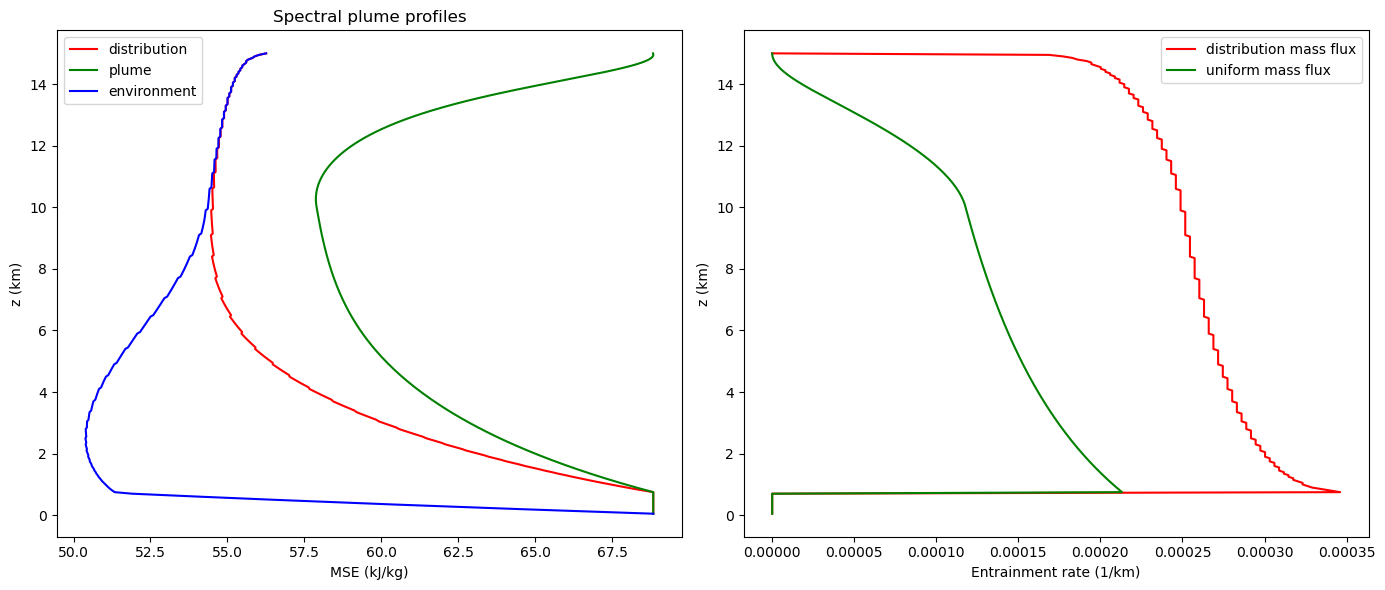

In [39]:
if __name__ == "__main__":
    output = spectral_plume_skew(model_type="precip",P=3,z_lcl=700,get_plane = False, 
                                 plotting=True, save_data=False,mprofile="cos",skew_type = "normal_narrow")
  

2.8465544533866646e-05 0.0001095790591175194


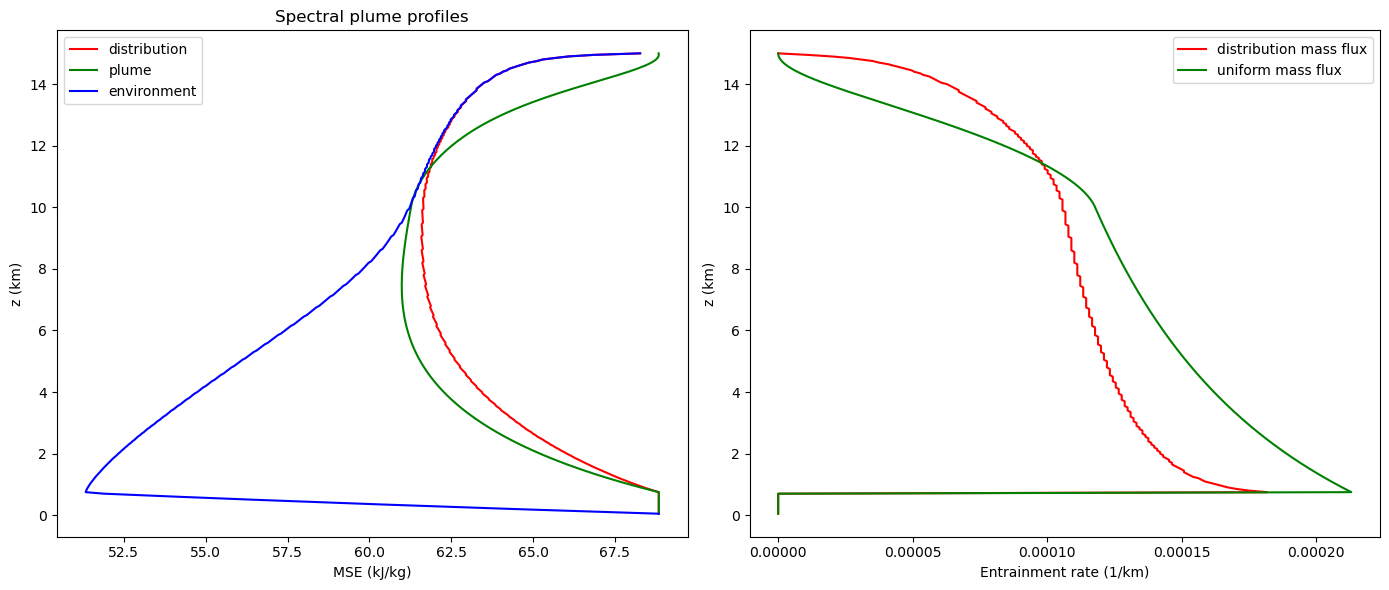

In [40]:
if __name__ == "__main__":
    output = spectral_plume_skew(model_type="precip",P=3,z_lcl=700,get_plane = False, 
                                 plotting=True, save_data=False,mprofile="cos",skew_type = "normal_wide")
  

In [17]:
2.8486696705919513e-05

2.8116964787602144e-06

In [29]:
2.8459921140909127e-02 - 2.8465544533866646e-02

-5.623392957520429e-06